# Fixed UEs, varying three-gNB overlap gap

This notebook keeps exactly the same six stationary UE coordinates and changes only the gNB positions:

- tight gap: outer gNBs at `x = ±220 m`;
- medium gap: outer gNBs at `x = ±270 m`;
- wide gap: outer gNBs at `x = ±320 m`.

All cells have a `500 m` coverage radius. Every UE is asserted to remain covered by all three gNBs in every topology.

In [1]:
import math
import os
import sys
from pathlib import Path

os.environ.setdefault("MPLCONFIGDIR", "/tmp/matplotlib-cache")

import matplotlib.pyplot as plt
from matplotlib.patches import Circle
import numpy as np

ROOT = Path.cwd()
if ROOT.name == "notebooks":
    ROOT = ROOT.parent
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from global_ppo_3gnb_env import GlobalPPO3GNBEnv
from upper_agent_training_scenarios import CENTER_GAP_GNB_CONFIGS

SCENARIO = "fixed_center_embb_left_right"
SEED = 123

In [2]:
def make_env(gnb_configs):
    return GlobalPPO3GNBEnv(
        seed=SEED,
        gnb_configs=gnb_configs,
        scenario_mode="curriculum",
        training_scenarios=SCENARIO,
        scenario_selection="cycle",
        upper_window_seconds=1.0,
        local_steps_per_global=10,
        radio_substeps=2,
        terminal_reward_only=False,
        max_handovers_per_local_step=3,
        a3_handover_cooldown_s=2.0,
        a3_min_residence_s=2.0,
    )


def center_release_action(bias=-0.8):
    action = np.zeros(9, dtype=np.float32)
    action[3] = bias
    return action


def covered_by(ue, gnb):
    return math.hypot(float(ue.x) - float(gnb.x), float(ue.y) - float(gnb.y)) <= float(gnb.coverage_radius)


records = []
reference_positions = None
for topology_name, gnb_configs in CENTER_GAP_GNB_CONFIGS.items():
    env = make_env(gnb_configs)
    _obs, reset_info = env.reset(seed=SEED)
    ues = list(env.base_env.get_all_ues())
    positions = tuple((float(ue.x), float(ue.y)) for ue in ues)
    if reference_positions is None:
        reference_positions = positions
    assert positions == reference_positions
    assert all(int(ue.serving_gnb) == 1 for ue in ues)
    assert all(float(ue.vx) == 0.0 and float(ue.vy) == 0.0 for ue in ues)

    coverage_matrix = np.array([
        [covered_by(ue, gnb) for gnb in env.base_env.gnbs]
        for ue in ues
    ], dtype=bool)
    assert coverage_matrix.all()

    outer_gap = abs(float(env.base_env.gnbs[0].x))
    radius = float(env.base_env.gnbs[0].coverage_radius)
    common_axis_width = 2.0 * (radius - outer_gap)

    _obs, reward, _terminated, _truncated, info = env.step(center_release_action())
    events = list(env.base_env.handover_events)
    records.append({
        "name": topology_name,
        "gnb_x": tuple(float(gnb.x) for gnb in env.base_env.gnbs),
        "positions": positions,
        "all3": int(np.sum(np.all(coverage_matrix, axis=1))),
        "common_axis_width": common_axis_width,
        "quota": int(info["safe_admission"]["quota"][(1, "eMBB")]),
        "handovers": int(info["handover_count"]),
        "left_hos": sum(event["to_gnb"] == 0 for event in events),
        "right_hos": sum(event["to_gnb"] == 2 for event in events),
        "loads_after": np.asarray(info["load_matrix"], dtype=float)[:, 0],
        "reward": float(reward),
    })
    env.close()

print(f"{'topology':>14} {'gNB x positions':>24} {'common width':>13} {'all-3':>6} {'HO L/R':>8} {'loads after':>20}")
for item in records:
    print(
        f"{item['name']:>14} {str(item['gnb_x']):>24} "
        f"{item['common_axis_width']:13.0f} {item['all3']:6d} "
        f"{item['left_hos']}/{item['right_hos']:>5d} "
        f"{np.round(item['loads_after'], 2).tolist()!s:>20}"
    )

      topology          gNB x positions  common width  all-3   HO L/R          loads after
    tight_220m     (-220.0, 0.0, 220.0)           560      6 2/    2      [0.3, 0.3, 0.3]
   medium_270m     (-270.0, 0.0, 270.0)           460      6 2/    2      [0.3, 0.3, 0.3]
     wide_320m     (-320.0, 0.0, 320.0)           360      6 2/    2      [0.3, 0.3, 0.3]


## Same UE dots, different cell overlap

The UE dots remain at identical absolute coordinates in all panels. Only the three coverage-circle centers move.

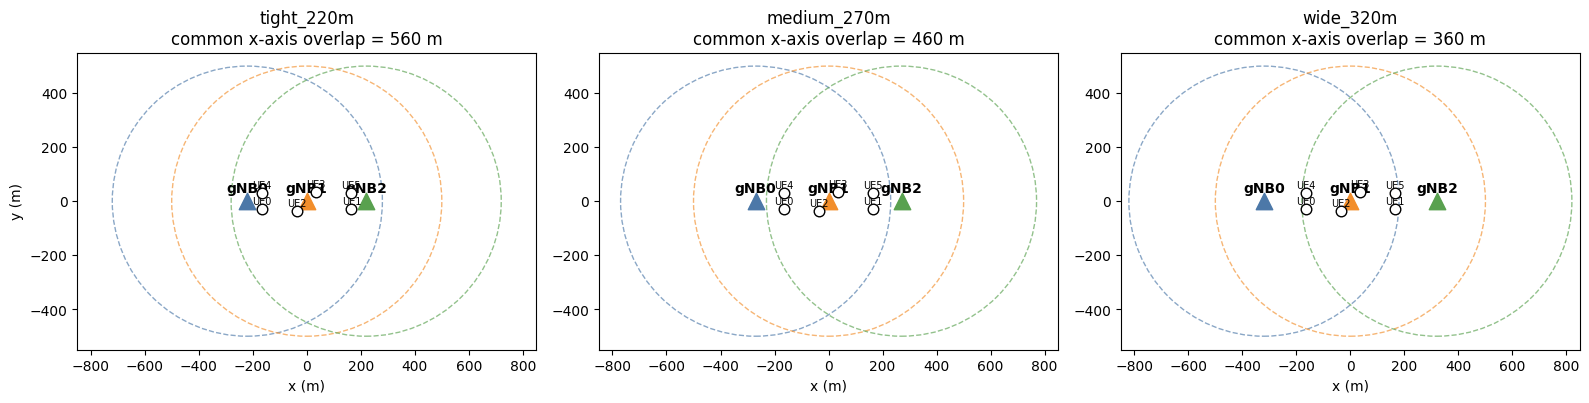

In [3]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
colors = ["#4C78A8", "#F28E2B", "#59A14F"]

for ax, item in zip(axes, records):
    for gnb_id, x in enumerate(item["gnb_x"]):
        ax.add_patch(Circle((x, 0.0), 500.0, fill=False, linestyle="--", color=colors[gnb_id], alpha=0.65))
        ax.scatter(x, 0.0, marker="^", s=140, color=colors[gnb_id], zorder=3)
        ax.text(x, 35, f"gNB{gnb_id}", ha="center", weight="bold")
    for ue_id, (x, y) in enumerate(item["positions"]):
        ax.scatter(x, y, s=58, facecolor="white", edgecolor="black", zorder=5)
        ax.text(x, y + 18, f"UE{ue_id}", ha="center", fontsize=7)
    ax.set_title(
        f"{item['name']}\ncommon x-axis overlap = {item['common_axis_width']:.0f} m"
    )
    ax.set_xlim(-850, 850)
    ax.set_ylim(-550, 550)
    ax.set_aspect("equal")
    ax.set_xlabel("x (m)")
axes[0].set_ylabel("y (m)")
plt.tight_layout()
plt.show()

## Verification

The common three-cell region becomes smaller as the gNB gap increases, but the UE placement is unchanged and remains feasible in all three variants.

In [4]:
widths = [item["common_axis_width"] for item in records]
assert widths == sorted(widths, reverse=True)
assert all(item["all3"] == 6 for item in records)
assert all(item["positions"] == reference_positions for item in records)
assert all(item["quota"] == 4 for item in records)
assert all(item["left_hos"] == 2 and item["right_hos"] == 2 for item in records)
assert all(np.allclose(item["loads_after"], [0.3, 0.3, 0.3]) for item in records)

print("PASS: only the gNB overlap gap changed; UE placement stayed identical and all UEs retained three-cell coverage.")

PASS: only the gNB overlap gap changed; UE placement stayed identical and all UEs retained three-cell coverage.
